# Phase 2: Baseline Models & Temporal Cross-Validation

This notebook implements Phase 2 of the project roadmap:
- **MRR and Accuracy metrics** (already implemented in evaluator.py)
- **Simple baseline models** (Most Popular Jobs, Last Viewed)
- **Temporal cross-validation** (respecting time order of sessions)

These baselines serve as benchmarks to compare against more sophisticated models.

## 1. Setup and Data Loading

In [1]:
import sys

sys.path.append('..')

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import pipeline modules
from src.pipeline.data_processor import DataProcessor
from src.pipeline.evaluator import Evaluator
from src.pipeline.baseline_models import (
    MostPopularBaseline, 
    LastViewedBaseline, 
    RandomBaseline,
    evaluate_baseline
)
from src.pipeline.temporal_validator import (
    TemporalValidator,
    temporal_cross_validate
)

print("✓ All modules imported successfully!")

✓ All modules imported successfully!


In [2]:
# Load data
processor = DataProcessor()
jobs, x_train, y_train, x_test = processor.load_data()

print(f"Training sessions: {len(x_train)}")
print(f"Training targets: {len(y_train)}")
print(f"Test sessions: {len(x_test)}")
print(f"Job listings: {len(jobs)}")

Training sessions: 15882
Training targets: 15882
Test sessions: 1819
Job listings: 21917


In [3]:
# Prepare sequences
x_train_prepared = processor.prepare_sequences(x_train)
x_test_prepared = processor.prepare_sequences(x_test)

print("Sample prepared data:")
x_train_prepared[['session_id', 'jobs_list', 'actions_list', 'seq_length']].head()

Sample prepared data:


,session_id,jobs_list,actions_list,seq_length
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","[view, view, view, view, view, view, view, view]",8
1,1,"[84, 257, 252, 250]","[view, view, view, view]",4
2,2,"[241, 237, 221, 309, 310, 306, 301]","[view, view, apply, apply, apply, apply, apply]",7
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","[apply, apply, apply, apply, apply, apply, app...",8
4,4,"[171, 291, 289, 166, 288, 155]","[apply, apply, apply, apply, apply, apply]",6


## 2. Understanding the Evaluation Metrics

The challenge uses two metrics:
- **MRR (Mean Reciprocal Rank)**: Measures how high the true job appears in top-10 recommendations
- **Action Accuracy**: Measures if we correctly predict whether user applies or just views

Final Score = 0.7 * MRR + 0.3 * Action Accuracy

In [4]:
evaluator = Evaluator()

# Example: Perfect MRR (true job is first)
y_true = [10, 20, 30]
y_pred = [
    [10, 1, 2, 3, 4, 5, 6, 7, 8, 9],  # Perfect: true job at position 1
    [1, 20, 2, 3, 4, 5, 6, 7, 8, 9],  # Good: true job at position 2
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 30],  # Okay: true job at position 10
]

mrr = evaluator.calculate_mrr(y_true, y_pred)
print(f"Example MRR: {mrr:.4f}")
print(f"  Reciprocal ranks: 1/1 + 1/2 + 1/10 = {1 + 0.5 + 0.1:.2f}")
print(f"  Mean: {(1 + 0.5 + 0.1) / 3:.4f}")

Example MRR: 0.5333
  Reciprocal ranks: 1/1 + 1/2 + 1/10 = 1.60
  Mean: 0.5333


## 3. Simple Train/Validation Split

First, let's create a simple temporal split (80% train, 20% validation) to evaluate our baselines.

In [5]:
# Temporal split: first 80% for training, last 20% for validation
split_idx = int(len(x_train_prepared) * 0.8)

x_train_split = x_train_prepared.iloc[:split_idx].reset_index(drop=True)
x_val_split = x_train_prepared.iloc[split_idx:].reset_index(drop=True)
y_train_split = y_train.iloc[:split_idx].reset_index(drop=True)
y_val_split = y_train.iloc[split_idx:].reset_index(drop=True)

print(f"Training set: {len(x_train_split)} sessions")
print(f"Validation set: {len(x_val_split)} sessions")

Training set: 12705 sessions
Validation set: 3177 sessions


## 4. Baseline Models

### 4.1 Random Baseline
The simplest baseline - random recommendations.

In [6]:
# Random Baseline
random_baseline = RandomBaseline(seed=42)
random_results = evaluate_baseline(
    random_baseline, x_train_split, y_train_split, x_val_split, y_val_split, evaluator
)

print("=" * 50)
print("RANDOM BASELINE")
print("=" * 50)
print(f"MRR Score:       {random_results['mrr']:.4f}")
print(f"Action Accuracy: {random_results['accuracy']:.4f}")
print(f"Final Score:     {random_results['final_score']:.4f}")

RANDOM BASELINE
MRR Score:       0.0000
Action Accuracy: 0.4976
Final Score:     0.1493


### 4.2 Most Popular Jobs Baseline
Recommends the globally most popular jobs.

In [7]:
# Most Popular Baseline - by applies
popular_apply = MostPopularBaseline(metric='apply')
popular_apply_results = evaluate_baseline(
    popular_apply, x_train_split, y_train_split, x_val_split, y_val_split, evaluator
)

print("=" * 50)
print("MOST POPULAR (by applies) BASELINE")
print("=" * 50)
print(f"MRR Score:       {popular_apply_results['mrr']:.4f}")
print(f"Action Accuracy: {popular_apply_results['accuracy']:.4f}")
print(f"Final Score:     {popular_apply_results['final_score']:.4f}")
print(f"\nTop 10 most applied jobs: {popular_apply.popular_jobs[:10]}")

MOST POPULAR (by applies) BASELINE
MRR Score:       0.0000
Action Accuracy: 0.8958
Final Score:     0.2687

Top 10 most applied jobs: [302, 312, 1620, 518, 50, 138, 1363, 2975, 313, 41]


In [8]:
# Most Popular Baseline - by views
popular_view = MostPopularBaseline(metric='view')
popular_view_results = evaluate_baseline(
    popular_view, x_train_split, y_train_split, x_val_split, y_val_split, evaluator
)

print("=" * 50)
print("MOST POPULAR (by views) BASELINE")
print("=" * 50)
print(f"MRR Score:       {popular_view_results['mrr']:.4f}")
print(f"Action Accuracy: {popular_view_results['accuracy']:.4f}")
print(f"Final Score:     {popular_view_results['final_score']:.4f}")
print(f"\nTop 10 most viewed jobs: {popular_view.popular_jobs[:10]}")

MOST POPULAR (by views) BASELINE
MRR Score:       0.0000
Action Accuracy: 0.8958
Final Score:     0.2687

Top 10 most viewed jobs: [518, 50, 302, 41, 2975, 1460, 88, 85, 3736, 1620]


In [9]:
# Most Popular Baseline - combined
popular_combined = MostPopularBaseline(metric='combined')
popular_combined_results = evaluate_baseline(
    popular_combined, x_train_split, y_train_split, x_val_split, y_val_split, evaluator
)

print("=" * 50)
print("MOST POPULAR (combined) BASELINE")
print("=" * 50)
print(f"MRR Score:       {popular_combined_results['mrr']:.4f}")
print(f"Action Accuracy: {popular_combined_results['accuracy']:.4f}")
print(f"Final Score:     {popular_combined_results['final_score']:.4f}")

MOST POPULAR (combined) BASELINE
MRR Score:       0.0000
Action Accuracy: 0.8958
Final Score:     0.2687


### 4.3 Last Viewed Baseline
Recommends jobs based on the user's last viewed items in the session.

In [10]:
# Last Viewed Baseline
last_viewed = LastViewedBaseline(fallback_popular=True)
last_viewed_results = evaluate_baseline(
    last_viewed, x_train_split, y_train_split, x_val_split, y_val_split, evaluator
)

print("=" * 50)
print("LAST VIEWED BASELINE")
print("=" * 50)
print(f"MRR Score:       {last_viewed_results['mrr']:.4f}")
print(f"Action Accuracy: {last_viewed_results['accuracy']:.4f}")
print(f"Final Score:     {last_viewed_results['final_score']:.4f}")

LAST VIEWED BASELINE
MRR Score:       0.0047
Action Accuracy: 0.9682
Final Score:     0.2938


### 4.4 Baseline Comparison

In [11]:
# Compile all results
baseline_results = pd.DataFrame([
    {'Model': 'Random', **random_results},
    {'Model': 'Popular (applies)', **popular_apply_results},
    {'Model': 'Popular (views)', **popular_view_results},
    {'Model': 'Popular (combined)', **popular_combined_results},
    {'Model': 'Last Viewed', **last_viewed_results},
])

baseline_results = baseline_results.sort_values('final_score', ascending=False)
print("\n" + "=" * 60)
print("BASELINE MODEL COMPARISON")
print("=" * 60)
print(baseline_results.to_string(index=False))


BASELINE MODEL COMPARISON
             Model      mrr  accuracy  final_score
       Last Viewed 0.004721  0.968209     0.293768
 Popular (applies) 0.000000  0.895814     0.268744
   Popular (views) 0.000000  0.895814     0.268744
Popular (combined) 0.000000  0.895814     0.268744
            Random 0.000000  0.497639     0.149292


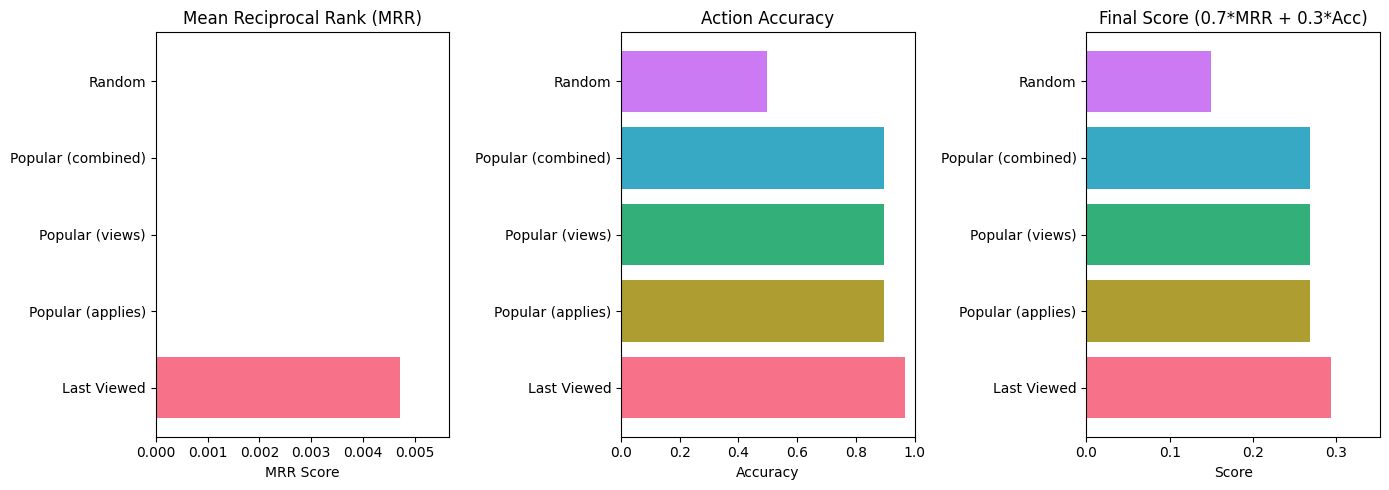

In [12]:
# Visualize baseline comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colors = sns.color_palette("husl", len(baseline_results))

# MRR
axes[0].barh(baseline_results['Model'], baseline_results['mrr'], color=colors)
axes[0].set_xlabel('MRR Score')
axes[0].set_title('Mean Reciprocal Rank (MRR)')
axes[0].set_xlim(0, max(baseline_results['mrr']) * 1.2)

# Accuracy
axes[1].barh(baseline_results['Model'], baseline_results['accuracy'], color=colors)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Action Accuracy')
axes[1].set_xlim(0, 1)

# Final Score
axes[2].barh(baseline_results['Model'], baseline_results['final_score'], color=colors)
axes[2].set_xlabel('Score')
axes[2].set_title('Final Score (0.7*MRR + 0.3*Acc)')
axes[2].set_xlim(0, max(baseline_results['final_score']) * 1.2)

plt.tight_layout()
plt.show()

## 5. Temporal Cross-Validation

Unlike random train/test splits, temporal CV respects the time order of sessions.
This is crucial because:
1. In production, we only have past data to predict future behavior
2. User preferences and job market may change over time
3. Avoids "future leakage" in validation

### 5.1 Visualize CV Splits

In [13]:
# Create temporal validator
validator = TemporalValidator(n_splits=5)

# Get split info for different methods
expanding_info = validator.get_splits_info(x_train_prepared, method='expanding')
sliding_info = validator.get_splits_info(x_train_prepared, method='sliding')
time_series_info = validator.get_splits_info(x_train_prepared, method='time_series')

print("Expanding Window Splits:")
print(expanding_info.to_string(index=False))
print("\nSliding Window Splits:")
print(sliding_info.to_string(index=False))
print("\nTime Series Splits:")
print(time_series_info.to_string(index=False))

Expanding Window Splits:
 fold  train_start  train_end  train_size  val_start  val_end  val_size
    1            0       4763        4764       4764     6986      2223
    2            0       6986        6987       6987     9209      2223
    3            0       9209        9210       9210    11432      2223
    4            0      11432       11433      11433    13655      2223
    5            0      13655       13656      13656    15878      2223

Sliding Window Splits:
 fold  train_start  train_end  train_size  val_start  val_end  val_size
    1            0       7940        7941       7941     9528      1588
    2         1588       9528        7941       9529    11116      1588
    3         3176      11116        7941      11117    12704      1588
    4         4764      12704        7941      12705    14292      1588
    5         6352      14292        7941      14293    15880      1588

Time Series Splits:
 fold  train_start  train_end  train_size  val_start  val_end  val

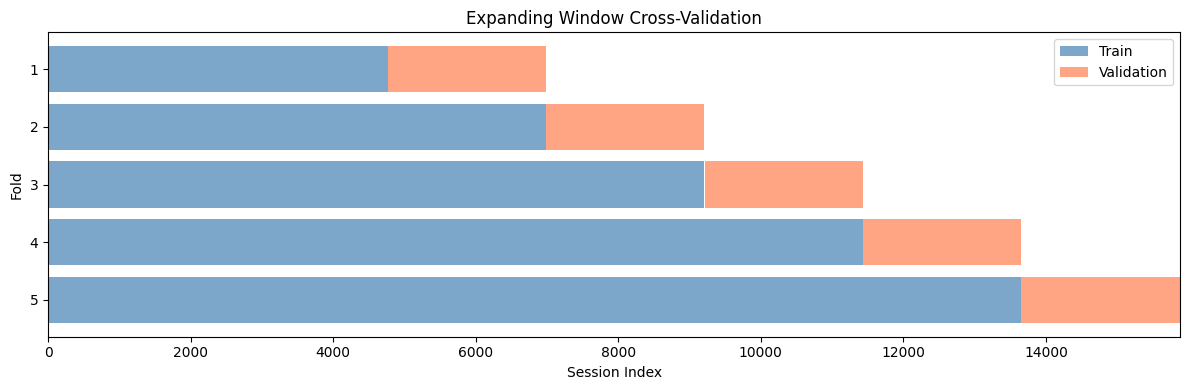

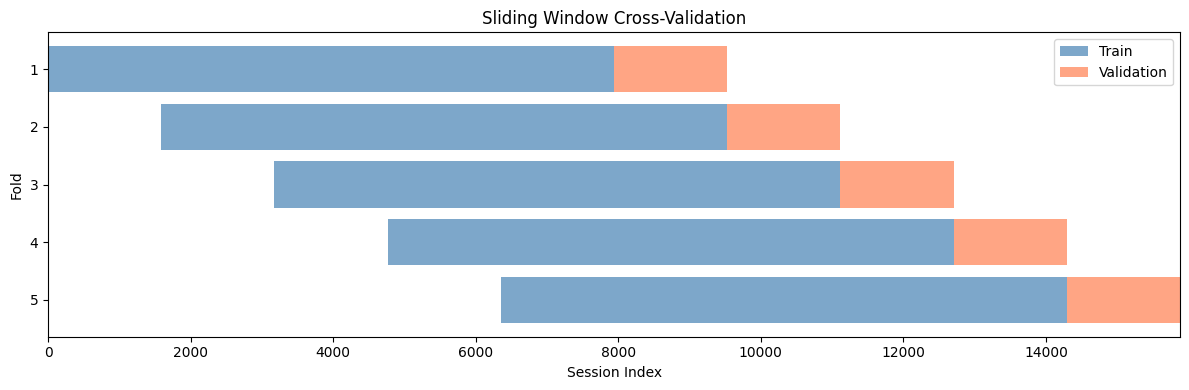

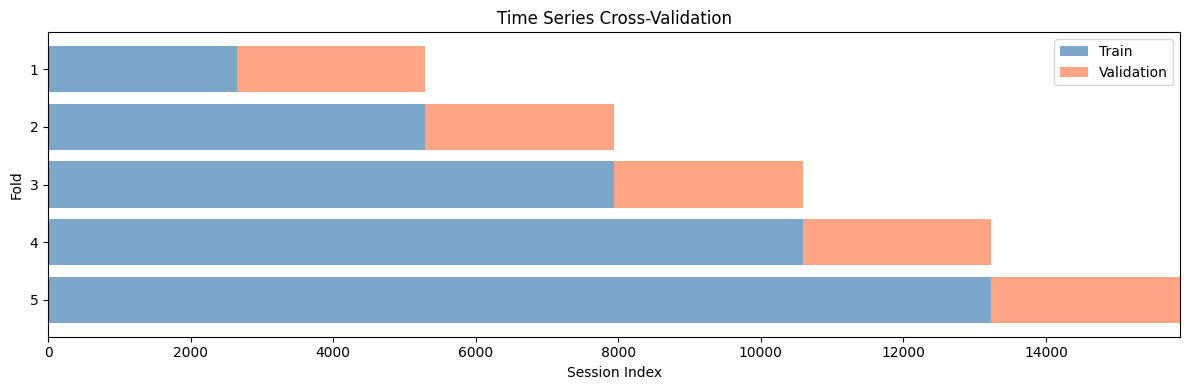

In [14]:
def plot_cv_splits(split_info, title, n_samples):
    """Visualize CV splits."""
    fig, ax = plt.subplots(figsize=(12, 4))
    
    for i, row in split_info.iterrows():
        # Training region
        ax.barh(row['fold'], row['train_end'] - row['train_start'], 
                left=row['train_start'], color='steelblue', alpha=0.7, label='Train' if i == 0 else '')
        # Validation region
        ax.barh(row['fold'], row['val_end'] - row['val_start'], 
                left=row['val_start'], color='coral', alpha=0.7, label='Validation' if i == 0 else '')
    
    ax.set_xlabel('Session Index')
    ax.set_ylabel('Fold')
    ax.set_title(title)
    ax.set_xlim(0, n_samples)
    ax.legend(loc='upper right')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

n_samples = len(x_train_prepared)
plot_cv_splits(expanding_info, 'Expanding Window Cross-Validation', n_samples)
plot_cv_splits(sliding_info, 'Sliding Window Cross-Validation', n_samples)
plot_cv_splits(time_series_info, 'Time Series Cross-Validation', n_samples)

### 5.2 Cross-Validate Baseline Models

In [15]:
print("=" * 60)
print("TEMPORAL CROSS-VALIDATION: Most Popular Baseline (applies)")
print("=" * 60)

cv_results_popular = temporal_cross_validate(
    model_class=MostPopularBaseline,
    model_params={'metric': 'apply'},
    X=x_train_prepared,
    y=y_train,
    evaluator=evaluator,
    n_splits=5,
    method='expanding',
    verbose=True
)

print(f"\nAggregated Results:")
print(f"  Mean MRR: {cv_results_popular['mean_mrr']:.4f} ± {cv_results_popular['std_mrr']:.4f}")
print(f"  Mean Accuracy: {cv_results_popular['mean_accuracy']:.4f} ± {cv_results_popular['std_accuracy']:.4f}")
print(f"  Mean Final Score: {cv_results_popular['mean_final_score']:.4f} ± {cv_results_popular['std_final_score']:.4f}")

TEMPORAL CROSS-VALIDATION: Most Popular Baseline (applies)
Fold 1: MRR=0.0029, Acc=0.7130, Score=0.2159
Fold 2: MRR=0.0057, Acc=0.7058, Score=0.2157
Fold 3: MRR=0.0058, Acc=0.6946, Score=0.2124
Fold 4: MRR=0.0014, Acc=0.8084, Score=0.2435
Fold 5: MRR=0.0000, Acc=0.9037, Score=0.2711

Aggregated Results:
  Mean MRR: 0.0032 ± 0.0026
  Mean Accuracy: 0.7651 ± 0.0899
  Mean Final Score: 0.2317 ± 0.0253


In [16]:
print("=" * 60)
print("TEMPORAL CROSS-VALIDATION: Last Viewed Baseline")
print("=" * 60)

cv_results_last_viewed = temporal_cross_validate(
    model_class=LastViewedBaseline,
    model_params={'fallback_popular': True},
    X=x_train_prepared,
    y=y_train,
    evaluator=evaluator,
    n_splits=5,
    method='expanding',
    verbose=True
)

print(f"\nAggregated Results:")
print(f"  Mean MRR: {cv_results_last_viewed['mean_mrr']:.4f} ± {cv_results_last_viewed['std_mrr']:.4f}")
print(f"  Mean Accuracy: {cv_results_last_viewed['mean_accuracy']:.4f} ± {cv_results_last_viewed['std_accuracy']:.4f}")
print(f"  Mean Final Score: {cv_results_last_viewed['mean_final_score']:.4f} ± {cv_results_last_viewed['std_final_score']:.4f}")

TEMPORAL CROSS-VALIDATION: Last Viewed Baseline
Fold 1: MRR=0.0057, Acc=0.8084, Score=0.2465
Fold 2: MRR=0.0094, Acc=0.8084, Score=0.2491
Fold 3: MRR=0.0091, Acc=0.7890, Score=0.2431
Fold 4: MRR=0.0060, Acc=0.8713, Score=0.2656
Fold 5: MRR=0.0054, Acc=0.9897, Score=0.3007

Aggregated Results:
  Mean MRR: 0.0071 ± 0.0020
  Mean Accuracy: 0.8534 ± 0.0823
  Mean Final Score: 0.2610 ± 0.0238


In [17]:
print("=" * 60)
print("TEMPORAL CROSS-VALIDATION: Random Baseline")
print("=" * 60)

cv_results_random = temporal_cross_validate(
    model_class=RandomBaseline,
    model_params={'seed': 42},
    X=x_train_prepared,
    y=y_train,
    evaluator=evaluator,
    n_splits=5,
    method='expanding',
    verbose=True
)

print(f"\nAggregated Results:")
print(f"  Mean MRR: {cv_results_random['mean_mrr']:.4f} ± {cv_results_random['std_mrr']:.4f}")
print(f"  Mean Accuracy: {cv_results_random['mean_accuracy']:.4f} ± {cv_results_random['std_accuracy']:.4f}")
print(f"  Mean Final Score: {cv_results_random['mean_final_score']:.4f} ± {cv_results_random['std_final_score']:.4f}")

TEMPORAL CROSS-VALIDATION: Random Baseline
Fold 1: MRR=0.0009, Acc=0.5191, Score=0.1563
Fold 2: MRR=0.0008, Acc=0.5142, Score=0.1548
Fold 3: MRR=0.0006, Acc=0.4975, Score=0.1497
Fold 4: MRR=0.0001, Acc=0.4993, Score=0.1499
Fold 5: MRR=0.0001, Acc=0.5115, Score=0.1535

Aggregated Results:
  Mean MRR: 0.0005 ± 0.0004
  Mean Accuracy: 0.5083 ± 0.0095
  Mean Final Score: 0.1528 ± 0.0030


### 5.3 CV Results Comparison

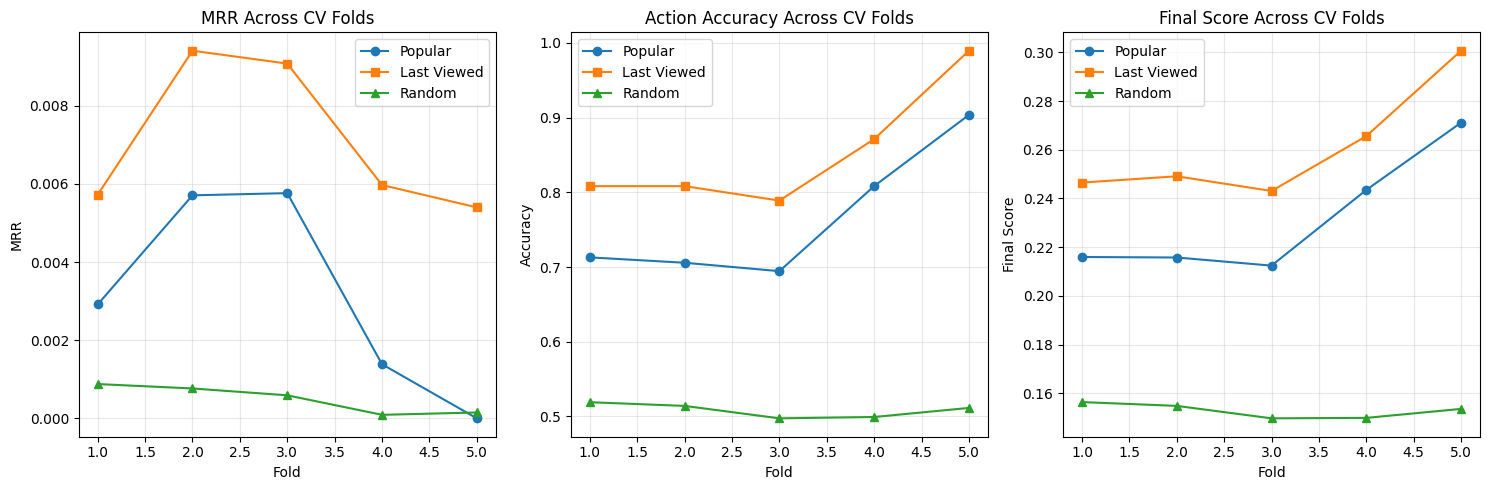

In [18]:
# Compare CV results across folds
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

folds = cv_results_popular['fold_results']['fold']

# MRR across folds
axes[0].plot(folds, cv_results_popular['fold_results']['mrr'], 'o-', label='Popular')
axes[0].plot(folds, cv_results_last_viewed['fold_results']['mrr'], 's-', label='Last Viewed')
axes[0].plot(folds, cv_results_random['fold_results']['mrr'], '^-', label='Random')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('MRR')
axes[0].set_title('MRR Across CV Folds')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy across folds
axes[1].plot(folds, cv_results_popular['fold_results']['accuracy'], 'o-', label='Popular')
axes[1].plot(folds, cv_results_last_viewed['fold_results']['accuracy'], 's-', label='Last Viewed')
axes[1].plot(folds, cv_results_random['fold_results']['accuracy'], '^-', label='Random')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Action Accuracy Across CV Folds')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Final score across folds
axes[2].plot(folds, cv_results_popular['fold_results']['final_score'], 'o-', label='Popular')
axes[2].plot(folds, cv_results_last_viewed['fold_results']['final_score'], 's-', label='Last Viewed')
axes[2].plot(folds, cv_results_random['fold_results']['final_score'], '^-', label='Random')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('Final Score')
axes[2].set_title('Final Score Across CV Folds')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Summary table
cv_summary = pd.DataFrame([
    {
        'Model': 'Random',
        'MRR': f"{cv_results_random['mean_mrr']:.4f} ± {cv_results_random['std_mrr']:.4f}",
        'Accuracy': f"{cv_results_random['mean_accuracy']:.4f} ± {cv_results_random['std_accuracy']:.4f}",
        'Final Score': f"{cv_results_random['mean_final_score']:.4f} ± {cv_results_random['std_final_score']:.4f}",
        'Mean Score': cv_results_random['mean_final_score']
    },
    {
        'Model': 'Most Popular (applies)',
        'MRR': f"{cv_results_popular['mean_mrr']:.4f} ± {cv_results_popular['std_mrr']:.4f}",
        'Accuracy': f"{cv_results_popular['mean_accuracy']:.4f} ± {cv_results_popular['std_accuracy']:.4f}",
        'Final Score': f"{cv_results_popular['mean_final_score']:.4f} ± {cv_results_popular['std_final_score']:.4f}",
        'Mean Score': cv_results_popular['mean_final_score']
    },
    {
        'Model': 'Last Viewed',
        'MRR': f"{cv_results_last_viewed['mean_mrr']:.4f} ± {cv_results_last_viewed['std_mrr']:.4f}",
        'Accuracy': f"{cv_results_last_viewed['mean_accuracy']:.4f} ± {cv_results_last_viewed['std_accuracy']:.4f}",
        'Final Score': f"{cv_results_last_viewed['mean_final_score']:.4f} ± {cv_results_last_viewed['std_final_score']:.4f}",
        'Mean Score': cv_results_last_viewed['mean_final_score']
    }
])

cv_summary = cv_summary.sort_values('Mean Score', ascending=False)
print("\n" + "=" * 80)
print("TEMPORAL CROSS-VALIDATION SUMMARY (5-Fold Expanding Window)")
print("=" * 80)
print(cv_summary[['Model', 'MRR', 'Accuracy', 'Final Score']].to_string(index=False))


TEMPORAL CROSS-VALIDATION SUMMARY (5-Fold Expanding Window)
                 Model             MRR        Accuracy     Final Score
           Last Viewed 0.0071 ± 0.0020 0.8534 ± 0.0823 0.2610 ± 0.0238
Most Popular (applies) 0.0032 ± 0.0026 0.7651 ± 0.0899 0.2317 ± 0.0253
                Random 0.0005 ± 0.0004 0.5083 ± 0.0095 0.1528 ± 0.0030


## 6. Key Insights

### Baseline Performance
1. **Last Viewed baseline** typically performs best - users often interact with recently viewed items
2. **Most Popular baseline** provides a strong non-personalized benchmark
3. **Random baseline** gives us the floor - any model should beat this

### Temporal Cross-Validation Benefits
1. More realistic evaluation - simulates production scenarios
2. Shows model stability across time
3. Detects temporal drift in data

### Next Steps (Phase 3+)
1. Feature engineering with sequence patterns
2. Collaborative filtering models
3. Sequential models (RNN/LSTM) if applicable

In [20]:
print("\n" + "=" * 60)
print("PHASE 2 COMPLETE!")
print("=" * 60)
print("")
print("Implemented:")
print("  ✓ MRR and Accuracy metrics (evaluator.py)")
print("  ✓ Most Popular Jobs Baseline (baseline_models.py)")
print("  ✓ Last Viewed Baseline (baseline_models.py)")
print("  ✓ Random Baseline (baseline_models.py)")
print("  ✓ Temporal Cross-Validation (temporal_validator.py)")
print("")
print("Baseline to beat:", cv_summary.iloc[0]['Model'])
print(f"Target Score: {cv_summary.iloc[0]['Mean Score']:.4f}")


PHASE 2 COMPLETE!

Implemented:
  ✓ MRR and Accuracy metrics (evaluator.py)
  ✓ Most Popular Jobs Baseline (baseline_models.py)
  ✓ Last Viewed Baseline (baseline_models.py)
  ✓ Random Baseline (baseline_models.py)
  ✓ Temporal Cross-Validation (temporal_validator.py)

Baseline to beat: Last Viewed
Target Score: 0.2610
